In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn import metrics

In [3]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

# 1

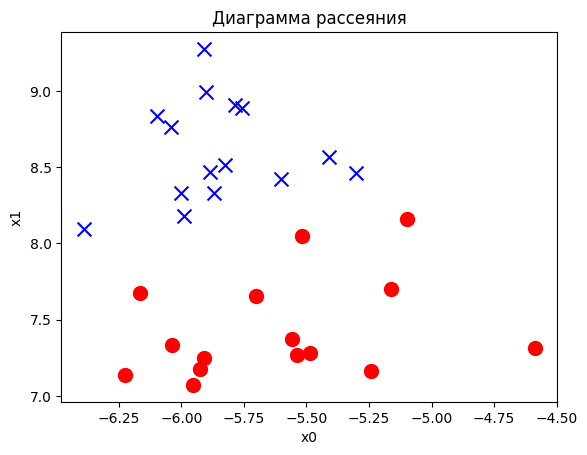

In [4]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

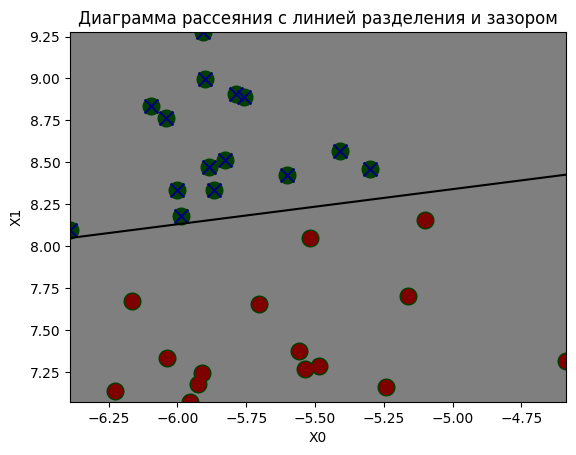

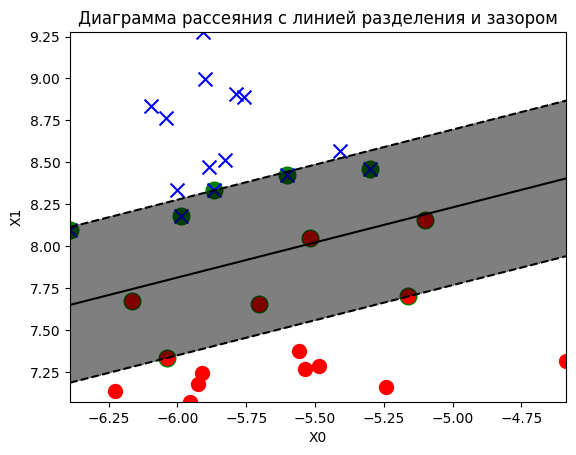

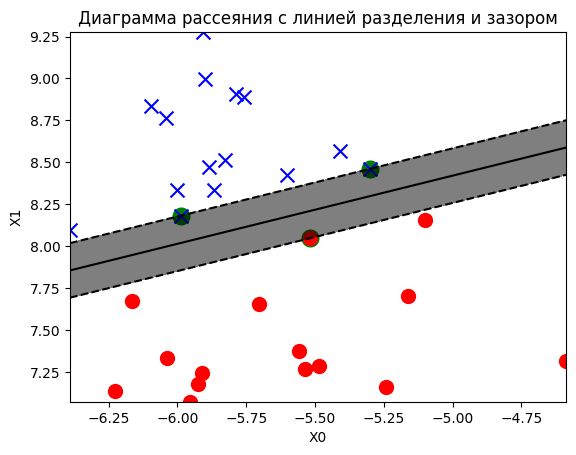

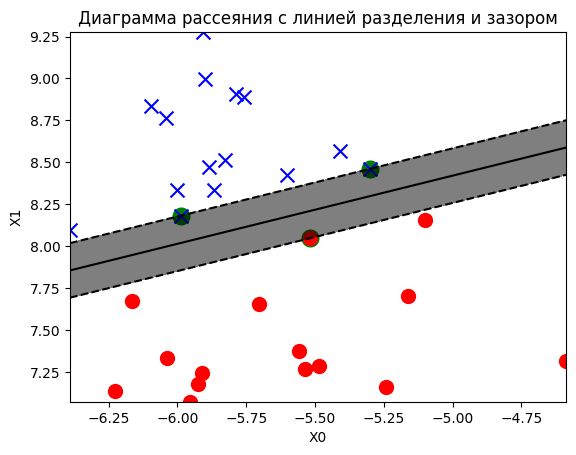

In [5]:
C_values = [0.01, 1, 100, 10000]
from sklearn.svm import SVC
for c in C_values:
    svm_linear = SVC(kernel='linear', C=c).fit(X, y)
    plot_decision_regions(X, y, svm_linear)

# 2

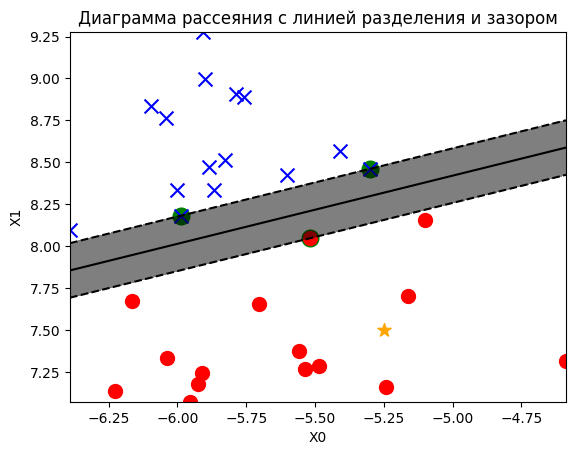

[0]


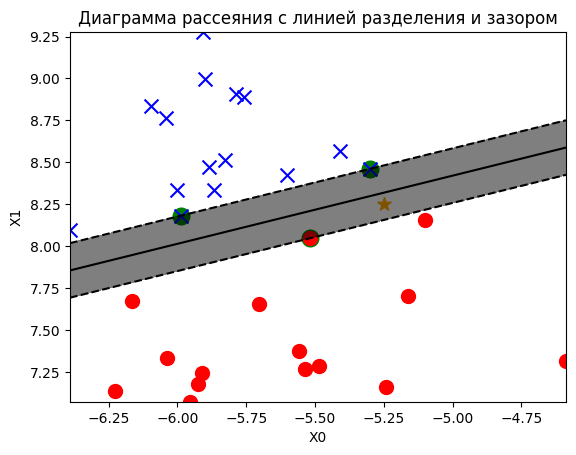

[0]


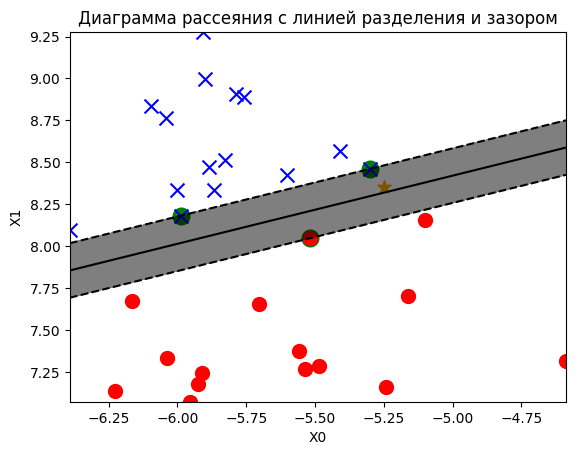

[1]


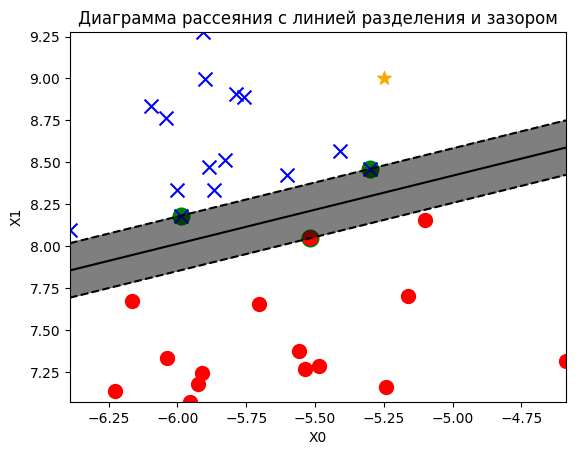

[1]


In [6]:
observations_new = [[-5.25, 7.5], [-5.25, 8.25], [-5.25, 8.35], [-5.25, 9.0]]
for observation in observations_new:
    plt.scatter(observation[0], observation[1], marker='*', s=100, color='orange')
    plot_decision_regions(X, y, svm_linear)
    print(svm_linear.predict([observation]))

# 3

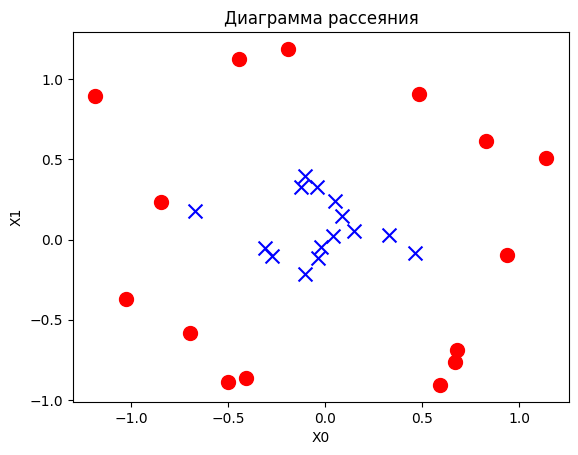

In [7]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

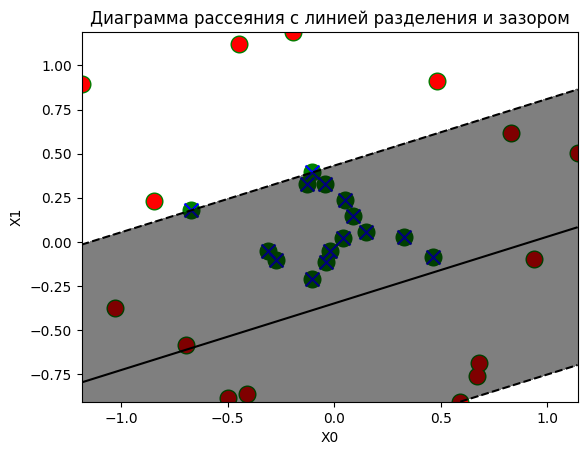

Kernel: linear
accuracy: 0.7


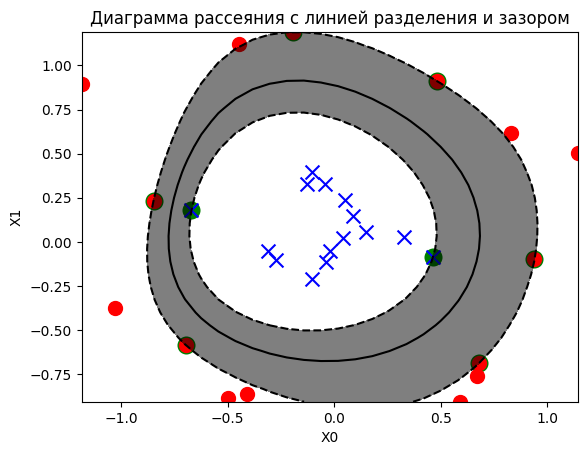

Kernel: rbf
accuracy: 1.0


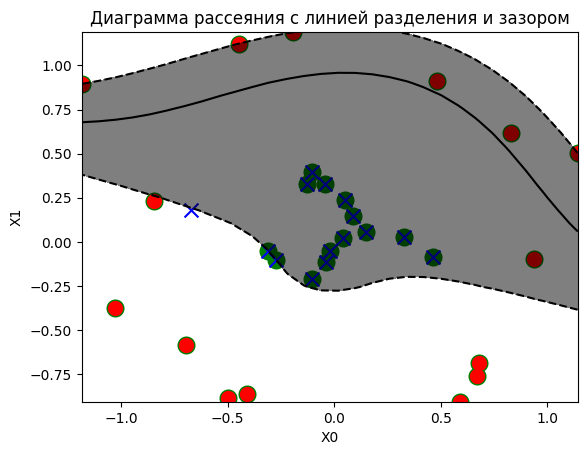

Kernel: poly
accuracy: 0.7


In [8]:
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    svm = SVC(kernel=kernel, C=100).fit(X, y)
    plot_decision_regions(X, y, svm)
    print(f"Kernel: {kernel}")
    print(f"accuracy: {metrics.accuracy_score(y, svm.predict(X))}")

# 4

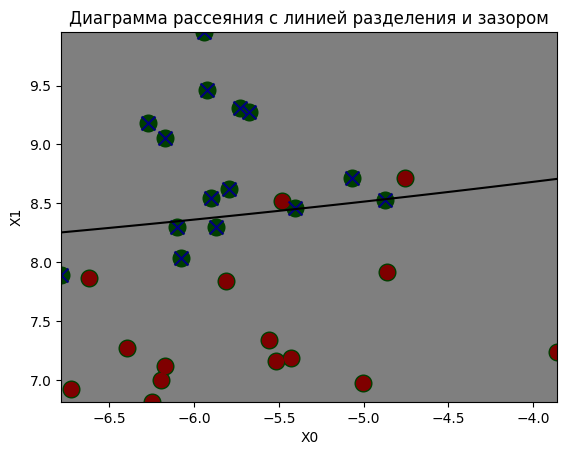

C: 0.1
Accuracy: 0.7666666666666667


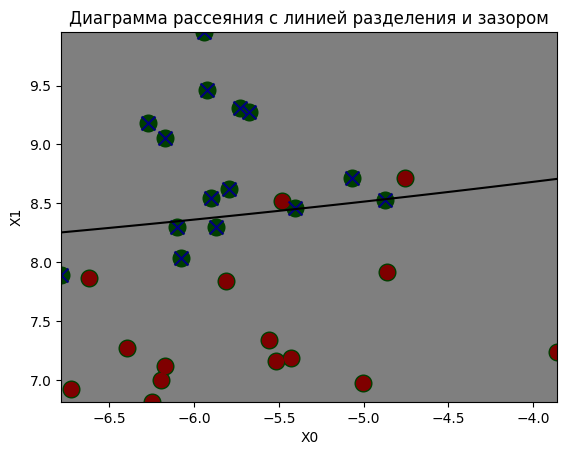

C: 1
Accuracy: 0.7666666666666667


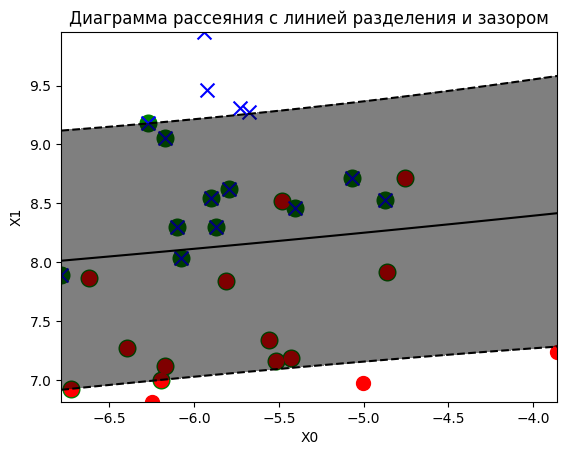

C: 5
Accuracy: 0.8666666666666667


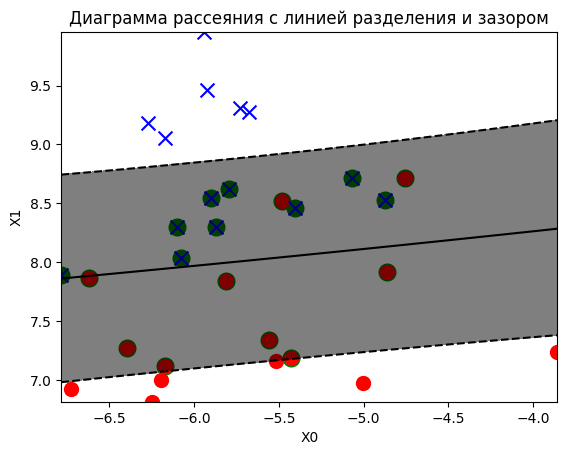

C: 10
Accuracy: 0.9333333333333333


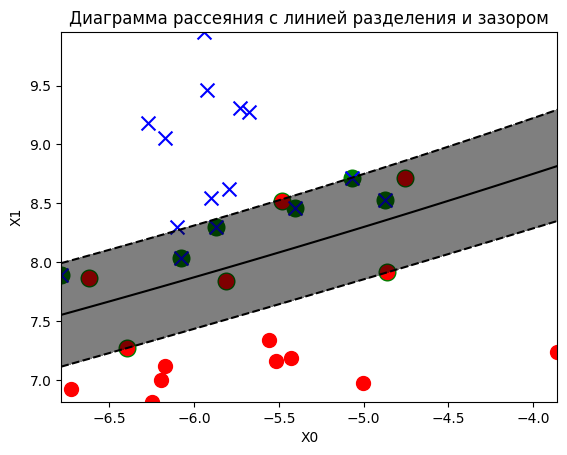

C: 100
Accuracy: 0.9


In [9]:
C_values = [0.1, 1, 5, 10, 100]
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)
for c in C_values:
    svm_rbf = SVC(kernel='rbf', C=c).fit(X, y)
    plot_decision_regions(X, y, svm_rbf)
    print(f"C: {c}")
    print(f"Accuracy: {metrics.accuracy_score(y, svm_rbf.predict(X))}")

# 5

In [10]:
from sklearn.svm import LinearSVC
svm_lin = LinearSVC(C=2, max_iter=10_000, random_state=5).fit(X, y)
print(f"Accuracy: {metrics.accuracy_score(y, svm_lin.predict(X))}")

Accuracy: 0.8333333333333334


# 6

In [11]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000,
                           n_features=5,
                           n_informative=3,
                           n_redundant=0,
                           n_classes=2,
                           random_state=42)

svc = SVC(kernel='rbf', C=20)
svc.fit(X, y)
print("accuracy:", metrics.accuracy_score(y, svc.predict(X)))

accuracy: 0.965


# 7

In [12]:
from time import perf_counter
t = perf_counter()
X, y = make_classification(n_samples=10000,
                           n_features=5,
                           n_informative=3,
                           n_redundant=0,
                           n_classes=2,
                           random_state=42)

svc = SVC(kernel='rbf', C=20)
svc.fit(X, y)
t = perf_counter() - t
print(f"training time: {t:.4f} seconds")
print("accuracy:", metrics.accuracy_score(y, svc.predict(X)))

training time: 1.6038 seconds
accuracy: 0.9387


# 8

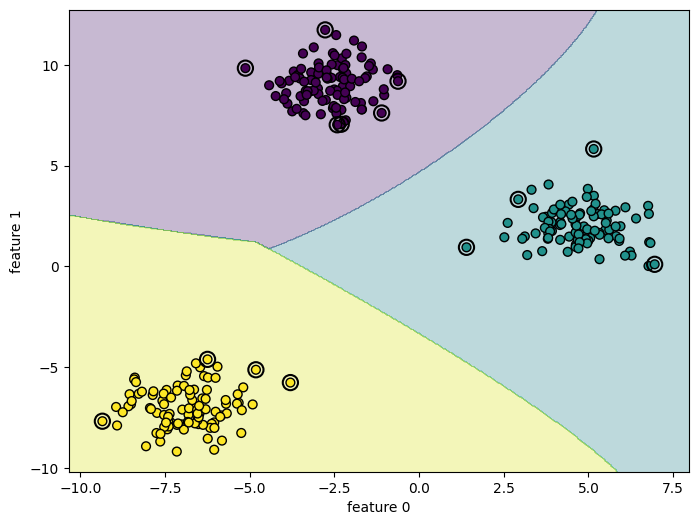

In [18]:
from itertools import combinations

X, y = make_blobs(n_samples=300, centers=3, n_features=2,
                  random_state=42, cluster_std=1.0)

svm = SVC(kernel='rbf', C=1).fit(X, y)


x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500)
x1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500)
X0g, X1g = np.meshgrid(x0, x1)
grid = np.c_[X0g.ravel(), X1g.ravel()]


Z = svm.predict(grid).reshape(X0g.shape)

plt.figure(figsize=(8, 6))
plt.contourf(X0g, X1g, Z, alpha=0.3, cmap='viridis')

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=40, edgecolor='k')

plt.scatter(svm.support_vectors_[:, 0],
            svm.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='k', linewidths=1.5)

plt.xlabel("feature 0")
plt.ylabel("feature 1")
plt.show()

# 9

accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



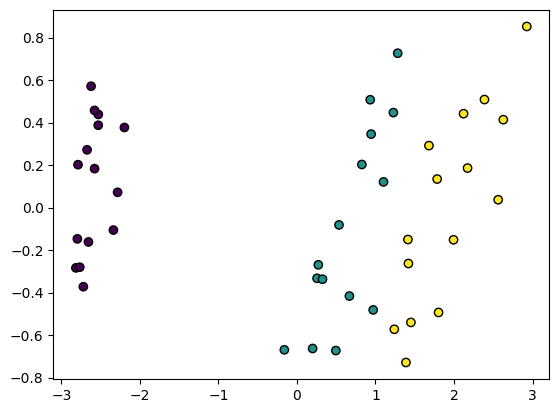

In [19]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

data = datasets.load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

svc = SVC(kernel='rbf', C=1.0, gamma='scale')
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=data.target_names))

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2 = pca.fit_transform(X_test)
plt.scatter(X2[:,0], X2[:,1], c=y_pred, cmap='viridis', edgecolor='k')
plt.show()

# 10

MSE: 1.3687197837110971
R²  : -0.02661416734766764


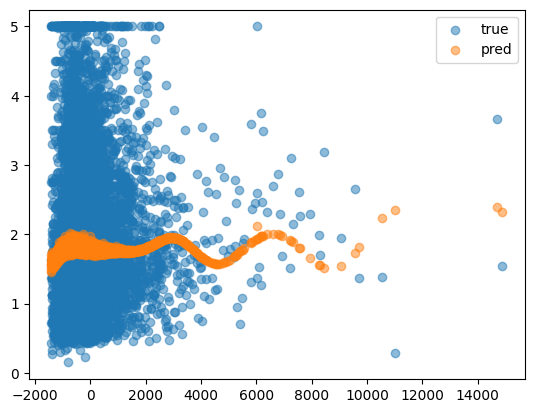

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR

data = datasets.fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))


pca = PCA(n_components=2)
X2 = pca.fit_transform(X_test)
plt.scatter(X2[:, 0], y_test, label='true', alpha=0.5)
plt.scatter(X2[:, 0], y_pred, label='pred', alpha=0.5)
plt.legend()
plt.show()